In [1]:
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

urllib.request.urlretrieve("https://archive.ics.uci.edu/static/public/481/emg+data+for+gestures.zip", "emg.zip")
zipfile.ZipFile("emg.zip").extractall()

In [2]:
import pandas as pd
df = pd.read_csv("EMG_data_for_gestures-master/01/1_raw_data_13-12_22.03.16.txt", sep="\t")
print(len(df))
print(list(df.columns))
print(df["class"].value_counts().sort_index())

63196
['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'channel7', 'channel8', 'class']
class
0    41272
1     3780
2     3525
3     3816
4     3441
5     3615
6     3747
Name: count, dtype: int64


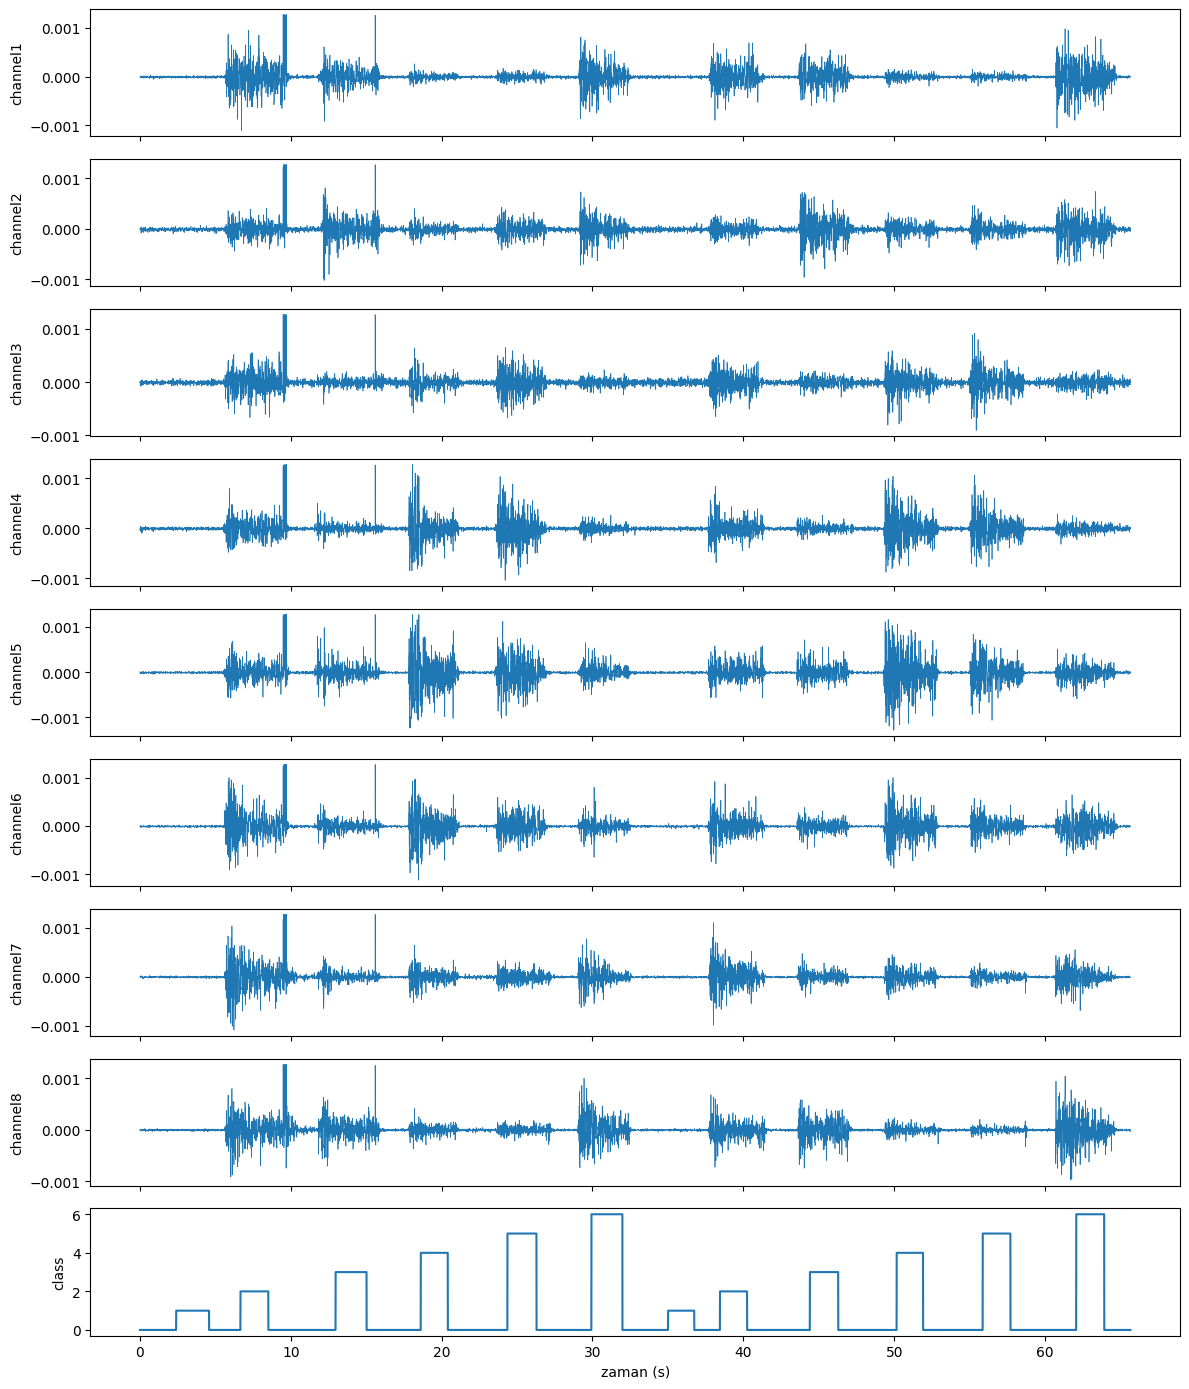

In [3]:
import matplotlib.pyplot as plt

t = df["time"] / 1000

fig, ax = plt.subplots(9, 1, sharex=True, figsize=(12, 14))

for i in range(8):
    kanal_adi = f"channel{i+1}"
    ax[i].plot(t, df[kanal_adi], linewidth=0.5)
    ax[i].set_ylabel(kanal_adi)

ax[8].plot(t, df["class"])
ax[8].set_ylabel("class")
ax[8].set_xlabel("zaman (s)")

plt.tight_layout()
plt.savefig("sekil1.png", dpi=100)
plt.show()

Grafikleri incelediğimde, class etiketinin yükseldiği anlar ile üstteki EMG kanallarındaki sinyal patlamalarının genel olarak aynı anda başladığını gözlemledim

In [4]:
import numpy as np

x = df["channel1"].abs()
d = x[df["class"] == 1]
esik = d.mean() + 3 * d.std()

tahmin = (x > esik).to_numpy()
gercek = df["class"].between(2, 7).to_numpy()
m = (df["class"] != 0).to_numpy()

def f1(tah, ger):
    TP = np.sum(tah & ger)
    FP = np.sum(tah & ~ger)
    FN = np.sum(~tah & ger)
    return 2 * TP / (2 * TP + FP + FN)

n = m.sum()

print(f"Baseline F1 = {round(f1(tahmin[m], gercek[m]), 3):.3f}")
print(f"Hep aktif F1 = {round(f1(np.ones(n, dtype=bool), gercek[m]), 3):.3f}")
print(f"Sağlama = {round(f1(gercek[m], gercek[m]), 3):.3f}")

Baseline F1 = 0.781
Hep aktif F1 = 0.906
Sağlama = 1.000


İlk yöntem F1 = 1.000
TP = 18144
FP = 0
FN = 0


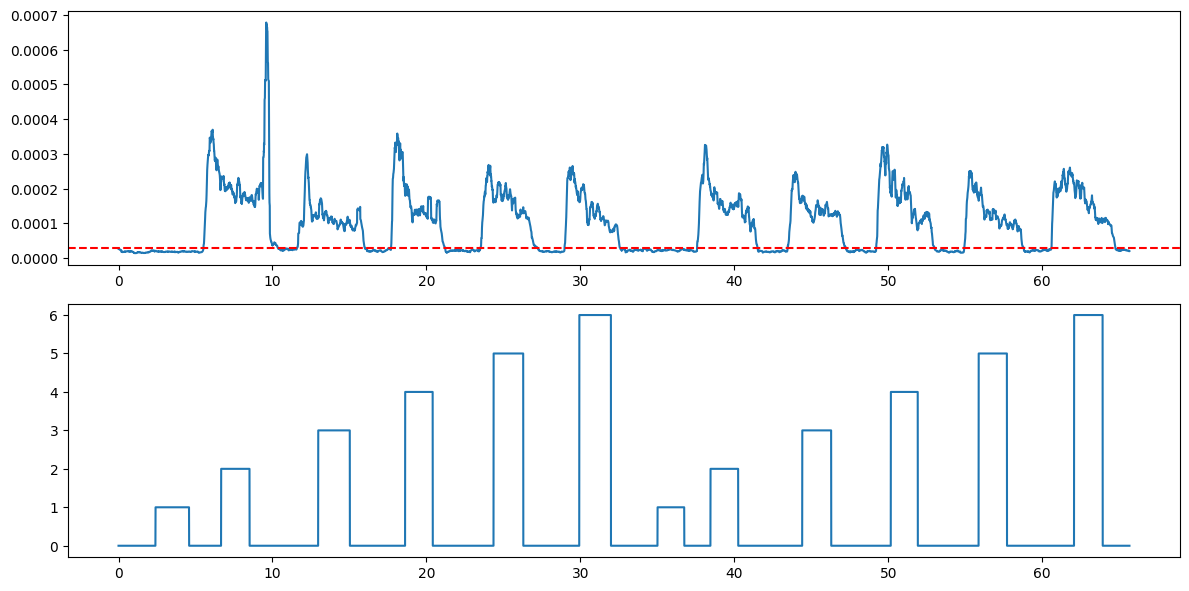

In [5]:
import numpy as np
import matplotlib.pyplot as plt

kanallar = [f"channel{i}" for i in range(1, 9)]
zarf = np.sqrt((df[kanallar] ** 2).rolling(200, center=True, min_periods=1).mean()).mean(axis=1)

d2 = zarf[df["class"] == 1]
esik2 = d2.mean() + 3 * d2.std()
tahmin2 = (zarf > esik2).to_numpy()

print(f"İlk yöntem F1 = {round(f1(tahmin2[m], gercek[m]), 3):.3f}")

TP2 = np.sum(tahmin2[m] & gercek[m])
FP2 = np.sum(tahmin2[m] & ~gercek[m])
FN2 = np.sum(~tahmin2[m] & gercek[m])

print(f"TP = {int(TP2)}")
print(f"FP = {int(FP2)}")
print(f"FN = {int(FN2)}")

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
x = df["time"] / 1000

ax[0].plot(x, zarf)
ax[0].axhline(y=esik2, color='red', linestyle='--')
ax[1].plot(x, df["class"])

plt.tight_layout()
plt.savefig("sekil2.png", dpi=100)
plt.show()

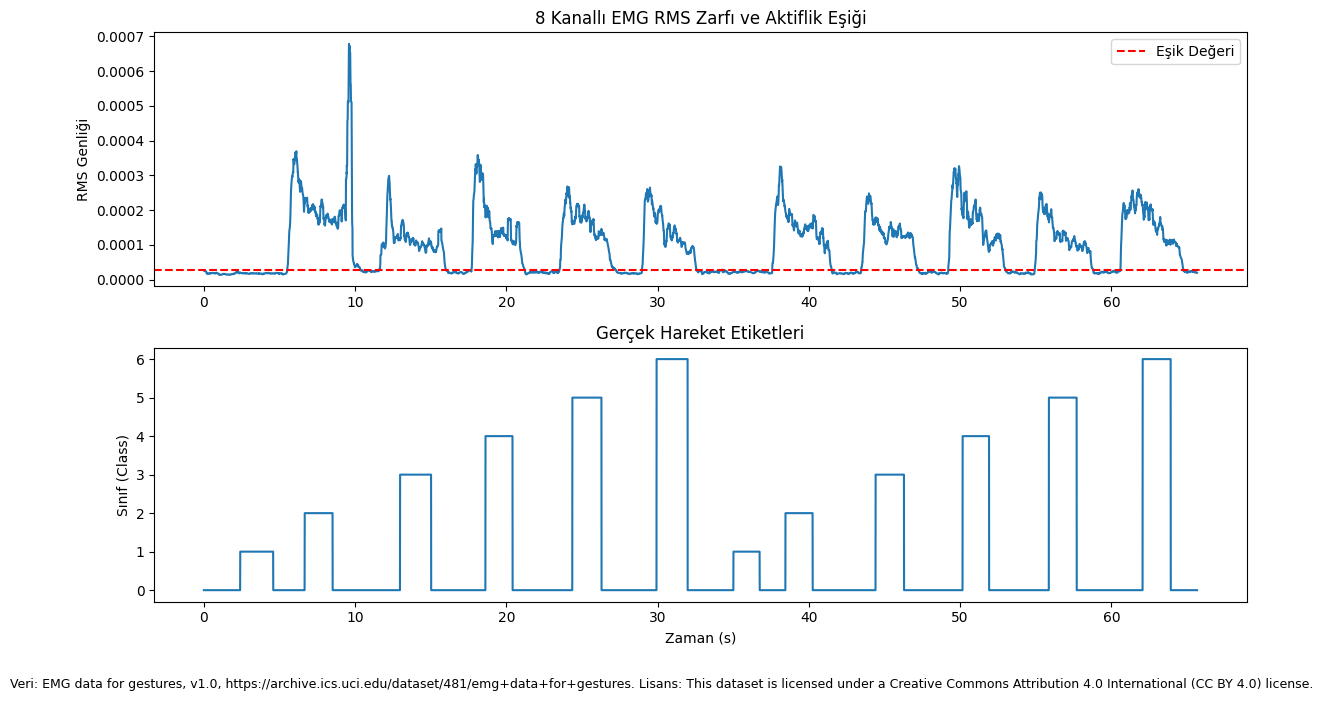

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
x_zaman = df["time"] / 1000

# Üst grafik: RMS Zarfı
ax[0].plot(x_zaman, zarf)
ax[0].axhline(y=esik2, color='red', linestyle='--', label='Eşik Değeri')
ax[0].set_title("8 Kanallı EMG RMS Zarfı ve Aktiflik Eşiği")
ax[0].set_ylabel("RMS Genliği")
ax[0].legend()

# Alt grafik: Etiketler
ax[1].plot(x_zaman, df["class"])
ax[1].set_title("Gerçek Hareket Etiketleri")
ax[1].set_ylabel("Sınıf (Class)")
ax[1].set_xlabel("Zaman (s)")

# Alt bilgiye yer açmak için grafikleri biraz yukarı sıkıştırıyoruz
plt.tight_layout(rect=[0, 0.05, 1, 1])

# Alt bilgi metni (LİSANSI_BURAYA_YAZIN kısmını siz dolduracaksınız)
alt_bilgi = "Veri: EMG data for gestures, v1.0, https://archive.ics.uci.edu/dataset/481/emg+data+for+gestures. Lisans: This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license."
plt.figtext(0.5, 0.01, alt_bilgi, ha="center", fontsize=9)

plt.savefig("sekil_github.png", dpi=100)
plt.show()